# Indicator selection and visual design

## Why these four indicators

The initial candidate indicators included `Arbeitslosenquote` and `SGB II - Quote`, because they are conceptually strong indicators for labour-market and social disadvantage. However, the INKAR 2025 metadata showed that these indicators are not available at Gemeinde level.

To avoid mixing spatial levels or using indicators that are not available for the selected geography, this workflow uses four indicators that are available for all 33 municipalities in the defined Dortmund StadtRegion in 2023:

- `population_change_5y_pct` — demographic change
- `share_65plus_pct` — demographic ageing
- `longterm_unemployed_share_pct` — labour-market exclusion
- `employment_rate_pct` — labour-market integration

## Classification and color choices

All maps use quantile classification with 5 classes. Quantiles are used as a comparison-oriented default because they create visually balanced classes across the 33 municipalities.

The color palettes are chosen according to the meaning of each indicator:

- Population change uses a diverging palette (`RdYlGn`) because zero is a meaningful midpoint between decline and growth.
- Share of population aged 65+ uses a sequential palette (`YlOrBr`) because it is a low-to-high percentage without a natural midpoint.
- Long-term unemployed share uses a sequential red palette (`OrRd`) because higher values indicate stronger labour-market exclusion.
- Employment rate uses a sequential green palette (`Greens`) because higher values indicate stronger labour-market integration.

No composite index is created at this stage, because combining indicators with different directions and scales would require explicit weighting decisions. For this demo, separate maps and a ranking table are more transparent.

In [3]:
# Cell 1 — setup

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROC = Path("../data/processed")
OUTPUT = Path("../output")
OUTPUT.mkdir(exist_ok=True)

stadtregion = gpd.read_file(PROC / "stadtregion_indicators_2023.gpkg")

print("Loaded:", len(stadtregion), "Gemeinden")
print("CRS:", stadtregion.crs)
print("Columns:")
print(list(stadtregion.columns))

stadtregion.head()

Loaded: 33 Gemeinden
CRS: EPSG:25832
Columns:
['AGS', 'GEN', 'BEZ', 'SN_L', 'Name', 'employment_rate_pct', 'population_change_5y_pct', 'share_65plus_pct', 'longterm_unemployed_share_pct', 'geometry']


,AGS,GEN,BEZ,SN_L,Name,employment_rate_pct,population_change_5y_pct,share_65plus_pct,longterm_unemployed_share_pct,geometry
0,05562004,Castrop-Rauxel,Stadt,05,"Castrop-Rauxel, Stadt",60.49,0.44,23.26,40.75,"MULTIPOLYGON (((383736.922 5719714.218, 383778..."
1,05562008,Datteln,Stadt,05,"Datteln, Stadt",62.46,2.50,23.25,59.18,"MULTIPOLYGON (((382518.798 5730443.1, 382555.2..."
2,05562012,Dorsten,Stadt,05,"Dorsten, Stadt",61.09,1.83,24.83,41.53,"MULTIPOLYGON (((367237.997 5738030.326, 367239..."
3,05562014,Gladbeck,Stadt,05,"Gladbeck, Stadt",57.79,-0.13,21.99,56.36,"MULTIPOLYGON (((360700.439 5721005.395, 360686..."
4,05562016,Haltern am See,Stadt,05,"Haltern am See, Stadt",64.34,0.25,24.86,33.25,"MULTIPOLYGON (((380772.678 5737897.376, 380744..."


In [5]:
# Cell 2 — reusable choropleth plotting function

def plot_choropleth(
    gdf,
    column,
    title,
    legend_title,
    cmap,
    output_path,
    scheme="quantiles",
    k=5,
    label_major_cities=True,
):
    """
    Render and save a choropleth map for one indicator.

    Parameters
    ----------
    gdf : GeoDataFrame
        Filtered Gemeinden in projected CRS.
    column : str
        Indicator column to map.
    title : str
        Map title.
    legend_title : str
        Legend title.
    cmap : str
        Matplotlib color map.
    output_path : Path
        PNG output path.
    scheme : str
        Classification scheme.
    k : int
        Number of classes.
    label_major_cities : bool
        Whether to label major cities.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column=column,
        cmap=cmap,
        scheme=scheme,
        k=k,
        legend=True,
        legend_kwds={
            "title": legend_title,
            "loc": "lower left",
            "fontsize": 9,
            "title_fontsize": 10,
        },
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
    )

    if label_major_cities:
        major_city_names = ["Dortmund", "Bochum", "Hagen", "Herne"]
        majors = gdf[gdf["GEN"].isin(major_city_names)]

        for _, row in majors.iterrows():
            centroid = row.geometry.centroid
            ax.annotate(
                row["GEN"],
                xy=(centroid.x, centroid.y),
                ha="center",
                fontsize=8,
                color="black",
                fontweight="bold",
            )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_axis_off()
    plt.tight_layout()

    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

    print("Saved:", output_path)

In [6]:
# Cell 3 — indicator metadata for all maps

INDICATORS = [
    {
        "column": "population_change_5y_pct",
        "title": "Population Change 2018–2023\nDortmund StadtRegion",
        "legend_title": "Population change\n2018–2023 (%)",
        "cmap": "RdYlGn",
        "filename": "01_population_change_stadtregion.png",
    },
    {
        "column": "share_65plus_pct",
        "title": "Share of Population Aged 65+, 2023\nDortmund StadtRegion",
        "legend_title": "Share 65+\n(%)",
        "cmap": "YlOrBr",
        "filename": "02_share_65plus_stadtregion.png",
    },
    {
        "column": "longterm_unemployed_share_pct",
        "title": "Long-term Unemployed Share, 2023\nDortmund StadtRegion",
        "legend_title": "Long-term unemployed\n(%)",
        "cmap": "OrRd",
        "filename": "03_longterm_unemployed_stadtregion.png",
    },
    {
        "column": "employment_rate_pct",
        "title": "Employment Rate, 2023\nDortmund StadtRegion",
        "legend_title": "Employment rate\n(%)",
        "cmap": "Greens",
        "filename": "04_employment_rate_stadtregion.png",
    },
]

# Sanity check distributions before plotting
for ind in INDICATORS:
    col = ind["column"]
    desc = stadtregion[col].describe()
    
    print(f"\n{col}:")
    print(f"  min: {desc['min']:.2f}")
    print(f"  mean: {desc['mean']:.2f}")
    print(f"  max: {desc['max']:.2f}")
    print(f"  missing: {stadtregion[col].isna().sum()}")


population_change_5y_pct:
  min: -4.69
  mean: -0.10
  max: 3.49
  missing: 0

share_65plus_pct:
  min: 20.39
  mean: 23.90
  max: 27.04
  missing: 0

longterm_unemployed_share_pct:
  min: 29.58
  mean: 41.26
  max: 59.18
  missing: 0

employment_rate_pct:
  min: 57.79
  mean: 62.75
  max: 68.81
  missing: 0


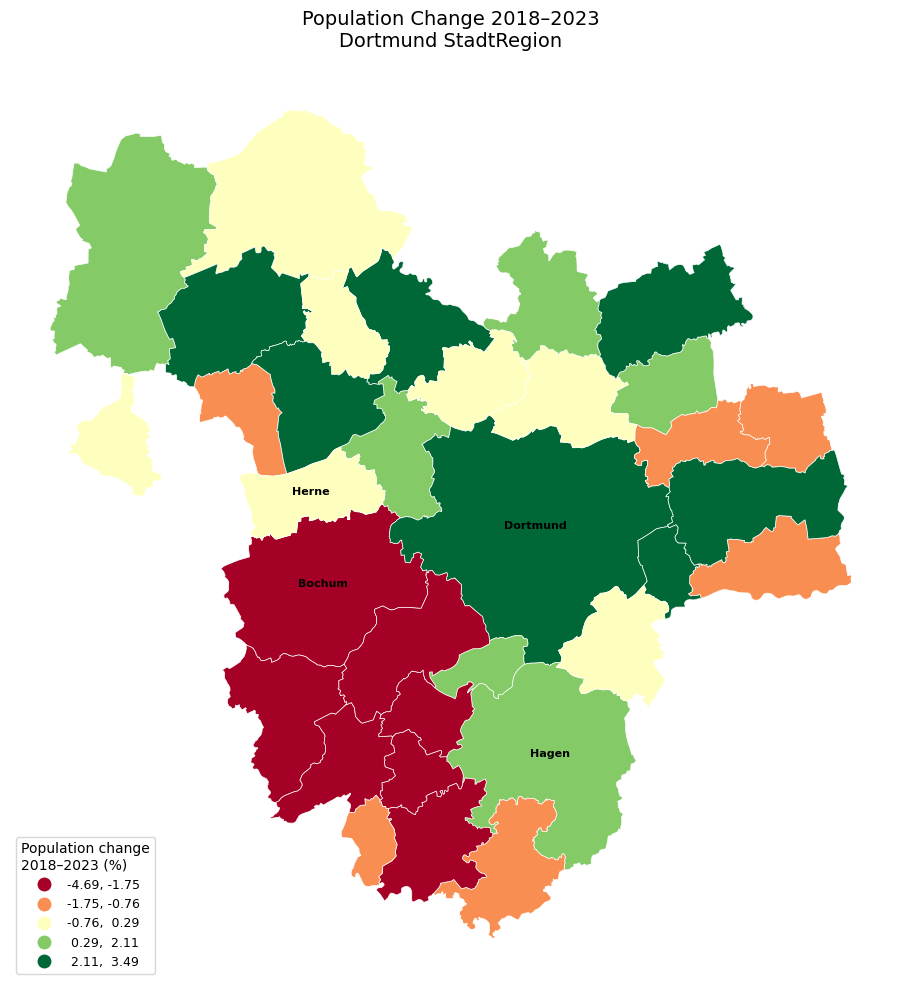

Saved: ..\output\01_population_change_stadtregion.png


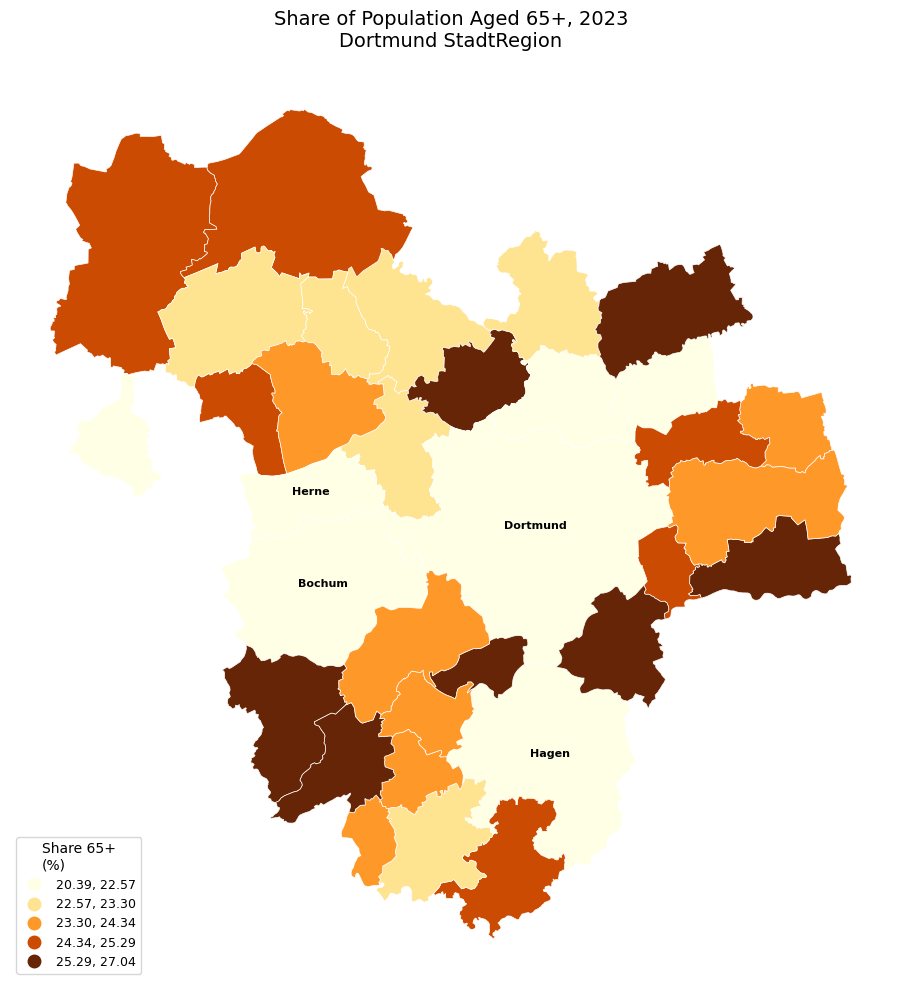

Saved: ..\output\02_share_65plus_stadtregion.png


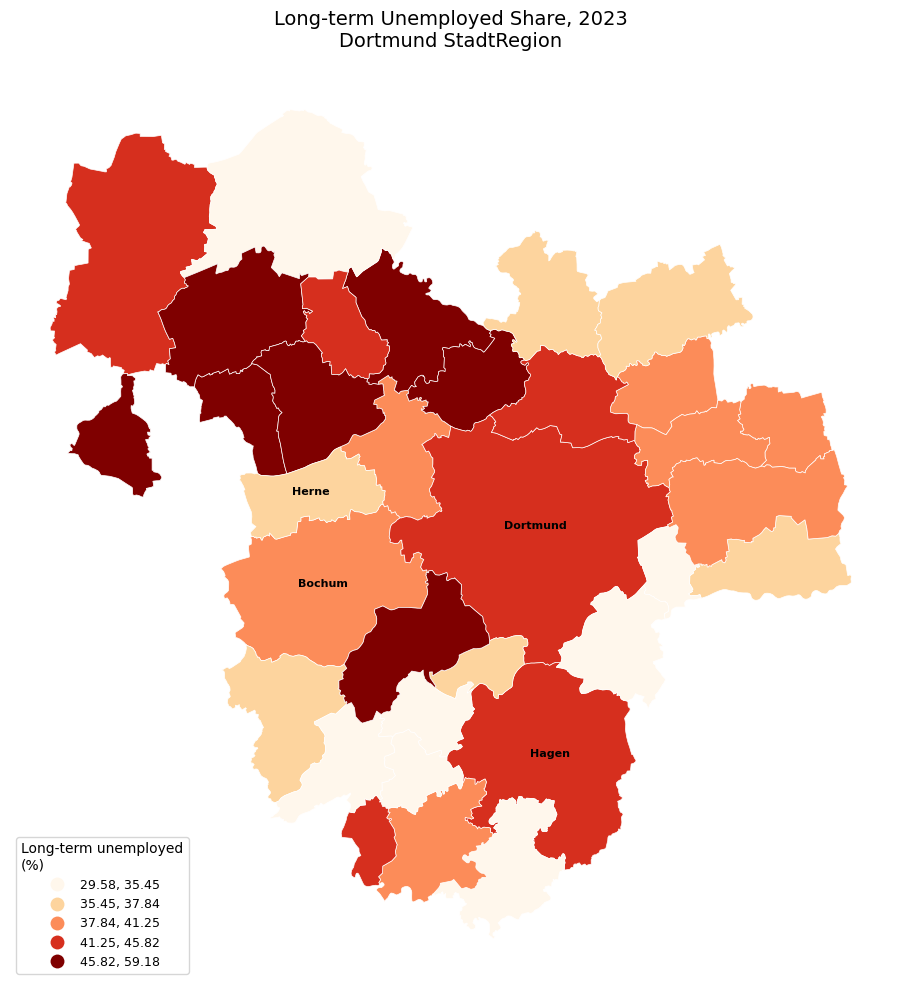

Saved: ..\output\03_longterm_unemployed_stadtregion.png


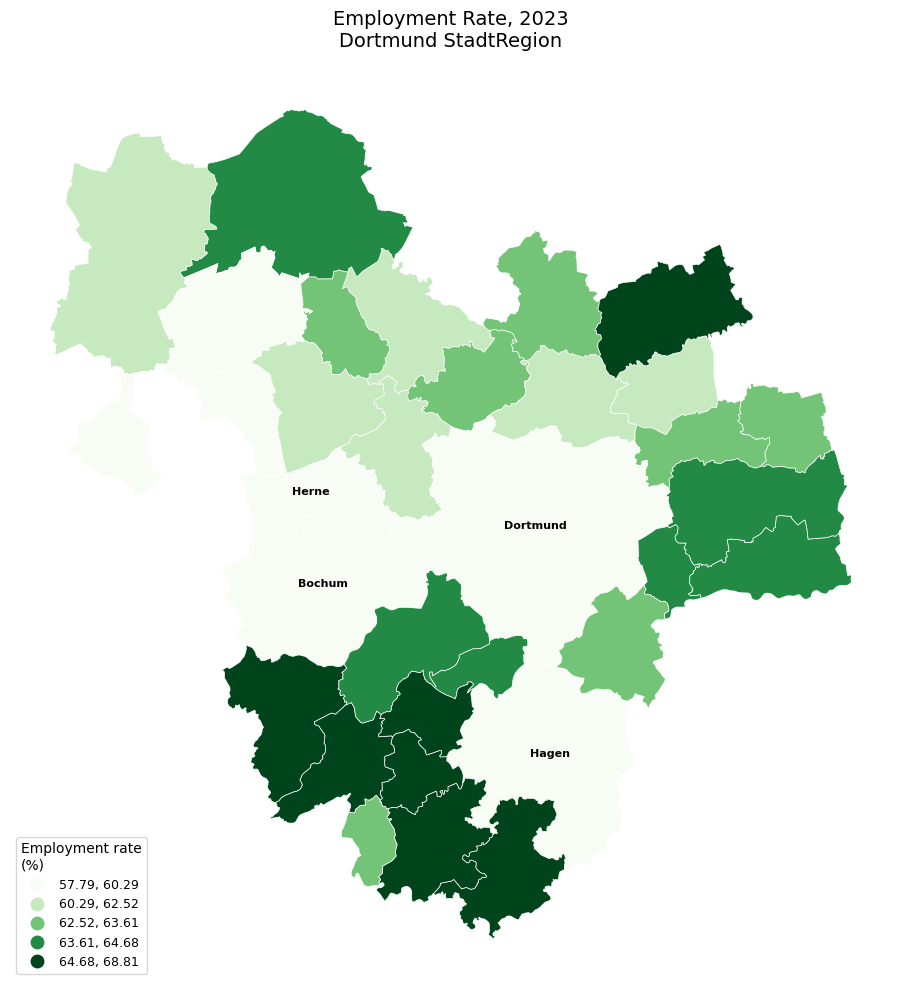

Saved: ..\output\04_employment_rate_stadtregion.png


In [7]:
# Cell 4 — generate all four choropleth maps

for ind in INDICATORS:
    plot_choropleth(
        gdf=stadtregion,
        column=ind["column"],
        title=ind["title"],
        legend_title=ind["legend_title"],
        cmap=ind["cmap"],
        output_path=OUTPUT / ind["filename"],
    )

In [8]:
# Cell 5 — ranking table

ranking_columns = [ind["column"] for ind in INDICATORS]

ranking_table = stadtregion[
    ["AGS", "GEN", "BEZ"] + ranking_columns
].copy()

# Sort by population change: highest growth first
ranking_table = ranking_table.sort_values(
    "population_change_5y_pct",
    ascending=False
)

# Round values for readability
for col in ranking_columns:
    ranking_table[col] = ranking_table[col].round(2)

print(ranking_table.to_string(index=False))

     AGS              GEN      BEZ  population_change_5y_pct  share_65plus_pct  longterm_unemployed_share_pct  employment_rate_pct
05978016      Holzwickede Gemeinde                      3.49             24.51                          34.84                64.60
05562024             Marl    Stadt                      3.27             23.28                          56.90                58.82
05562032   Recklinghausen    Stadt                      2.79             23.57                          46.55                60.74
05978040            Werne    Stadt                      2.52             26.13                          36.00                64.68
05562008          Datteln    Stadt                      2.50             23.25                          59.18                62.46
05913000         Dortmund    Stadt                      2.44             20.39                          43.90                58.04
05978036             Unna    Stadt                      2.29             24.31     

In [9]:
# Cell 6 — save ranking table as CSV

ranking_out = OUTPUT / "ranking_table.csv"

ranking_table.to_csv(
    ranking_out,
    index=False,
    encoding="utf-8"
)

print("Saved:", ranking_out)
print("Rows:", len(ranking_table))
print("Columns:", list(ranking_table.columns))

Saved: ..\output\ranking_table.csv
Rows: 33
Columns: ['AGS', 'GEN', 'BEZ', 'population_change_5y_pct', 'share_65plus_pct', 'longterm_unemployed_share_pct', 'employment_rate_pct']
